# 03. Modeling — K-Means Segmentation & Churn Prediction

**목표:**  
- **Part 1.** K-Means로 고객 클러스터링 → RFM 기반 세그먼트 검증  
- **Part 2.** 이탈 예측 분류 모델 (Logistic Regression / Random Forest) → 평가 및 피처 중요도  

**이전:** `02_feature_engineering.ipynb` → `data/processed/rfm.parquet`  
**다음:** `04_insights.ipynb`

## 0. Setup

In [1]:
import sys
sys.path.append("../../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from shared.plot_config import set_style
set_style()

RFM_PATH = "../data/processed/rfm.parquet"
MODEL_OUTPUT = "../data/processed/rfm_clustered.parquet"

## 1. 데이터 로딩

In [2]:
rfm = pd.read_parquet(RFM_PATH)
print(f"Shape: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")
rfm.head()

Shape: (5878, 10)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'Segment', 'Churned']


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Churned
0,12346,326,12,77556.46,2,5,5,12,At Risk,1
1,12347,2,8,5633.32,5,4,5,14,Champions,0
2,12348,75,5,2019.40,3,4,4,11,Loyal,0
3,12349,19,4,4428.69,4,3,5,12,Loyal,0
4,12350,310,1,334.40,2,1,2,5,Lost,1


# ─────────────────────────────────────────────
# PART 1. K-Means 세그멘테이션
# ─────────────────────────────────────────────

## 2. 피처 준비 (Log Transform + Scaling)

RFM은 심하게 오른쪽으로 치우친 분포 → log 변환으로 정규화 후 표준화

In [3]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_log["Recency"]   = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"]  = np.log1p(rfm_log["Monetary"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log)

print("Log + Scale 완료")
pd.DataFrame(X_scaled, columns=["Recency", "Frequency", "Monetary"]).describe().round(3)

Log + Scale 완료


,Recency,Frequency,Monetary
count,5878.000,5878.000,5878.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-2.412,-1.058,-3.936
25%,-0.743,-1.058,-0.706
50%,0.077,-0.202,-0.025
75%,0.955,0.655,0.654
max,1.380,5.485,4.671


## 3. Elbow Method — 최적 K 탐색

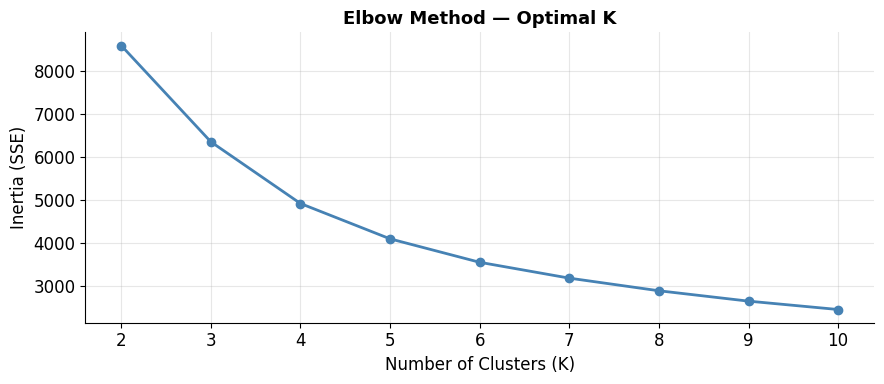

In [4]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_range, inertias, marker="o", color="steelblue", linewidth=2)
ax.set_title("Elbow Method — Optimal K", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (SSE)")
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.savefig("../outputs/figures/elbow.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. K-Means 클러스터링 (K=4)

In [5]:
K = 4  # Elbow 결과 보고 조정 가능

km = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = km.fit_predict(X_scaled)

cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
cluster_profile["count"] = rfm.groupby("Cluster")["Customer ID"].count()
cluster_profile = cluster_profile.sort_values("Monetary", ascending=False)
print(cluster_profile)

         Recency  Frequency  Monetary  count
Cluster                                     
0           27.4       19.3   11014.4   1188
2          227.9        5.1    2002.1   1465
3           28.4        3.0     865.1   1251
1          395.9        1.4     325.7   1974


## 5. 클러스터 시각화

### 5-1. PCA 2D 산점도

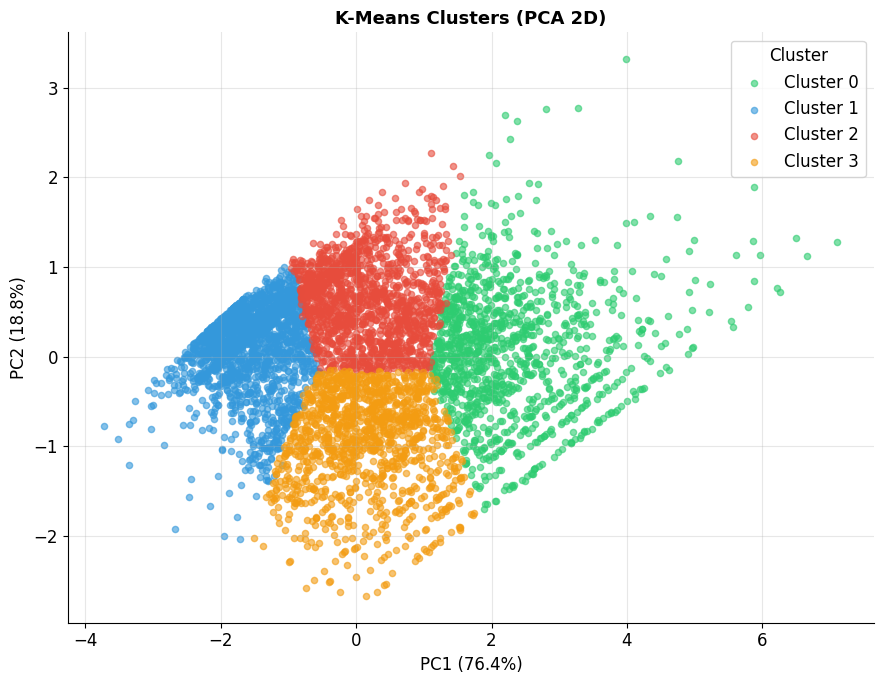

In [6]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]
fig, ax = plt.subplots(figsize=(9, 7))

for c in range(K):
    mask = rfm["Cluster"] == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colors[c], label=f"Cluster {c}", alpha=0.6, s=20)

ax.set_title("K-Means Clusters (PCA 2D)", fontsize=13, fontweight="bold")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.legend(title="Cluster")
plt.tight_layout()
plt.savefig("../outputs/figures/kmeans_pca.png", dpi=150, bbox_inches="tight")
plt.show()

### 5-2. 클러스터별 RFM 프로파일 (Radar Chart)

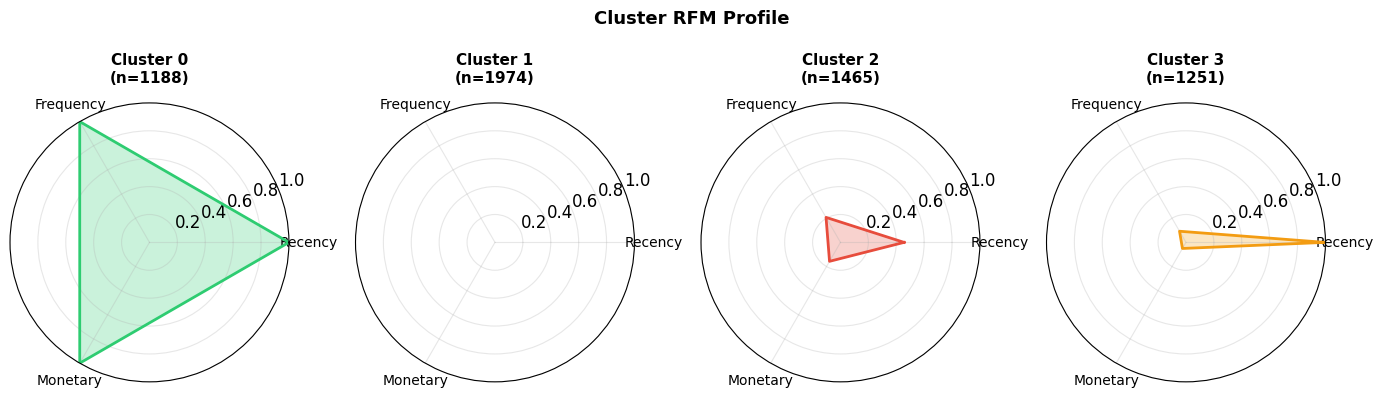

In [7]:
# 클러스터별 평균값을 0~1로 정규화하여 레이더 차트
from matplotlib.patches import FancyArrowPatch

features = ["Recency", "Frequency", "Monetary"]
cluster_means = rfm.groupby("Cluster")[features].mean()

# Recency는 낮을수록 좋으므로 역정규화
norm = cluster_means.copy()
for col in features:
    mn, mx = cluster_means[col].min(), cluster_means[col].max()
    if col == "Recency":
        norm[col] = 1 - (cluster_means[col] - mn) / (mx - mn)
    else:
        norm[col] = (cluster_means[col] - mn) / (mx - mn)

angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K, figsize=(14, 4), subplot_kw=dict(polar=True))
for idx, (cluster_id, row) in enumerate(norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    axes[idx].plot(angles, vals, color=colors[idx], linewidth=2)
    axes[idx].fill(angles, vals, color=colors[idx], alpha=0.25)
    axes[idx].set_xticks(angles[:-1])
    axes[idx].set_xticklabels(features, fontsize=10)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_title(f"Cluster {cluster_id}\n(n={cluster_profile.loc[cluster_id,'count'] if cluster_id in cluster_profile.index else rfm['Cluster'].value_counts()[cluster_id]})",
                        fontsize=11, fontweight="bold", pad=15)

plt.suptitle("Cluster RFM Profile", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# PART 2. 이탈 예측 (Churn Prediction)
# ─────────────────────────────────────────────

## 6. 피처 & 레이블 준비

In [8]:
FEATURES = ["Recency", "Frequency", "Monetary", "R_score", "F_score", "M_score", "RFM_score"]
TARGET = "Churned"

X = rfm[FEATURES].copy()
y = rfm[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_clf = StandardScaler()
X_train_s = scaler_clf.fit_transform(X_train)
X_test_s  = scaler_clf.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"이탈 비율 — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Train: (4702, 7) | Test: (1176, 7)
이탈 비율 — Train: 0.509 | Test: 0.509


## 7. 모델 학습 및 평가

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    X_tr = X_train_s if name == "Logistic Regression" else X_train
    X_te = X_test_s  if name == "Logistic Regression" else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {"model": model, "y_pred": y_pred, "y_prob": y_prob, "auc": auc}
    print(f"\n{'='*45}")
    print(f"  {name}  (AUC: {auc:.4f})")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))


  Logistic Regression  (AUC: 1.0000)
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       578
     Churned       1.00      0.98      0.99       598

    accuracy                           0.99      1176
   macro avg       0.99      0.99      0.99      1176
weighted avg       0.99      0.99      0.99      1176




  Random Forest  (AUC: 1.0000)
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00       578
     Churned       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



## 8. ROC Curve & Confusion Matrix

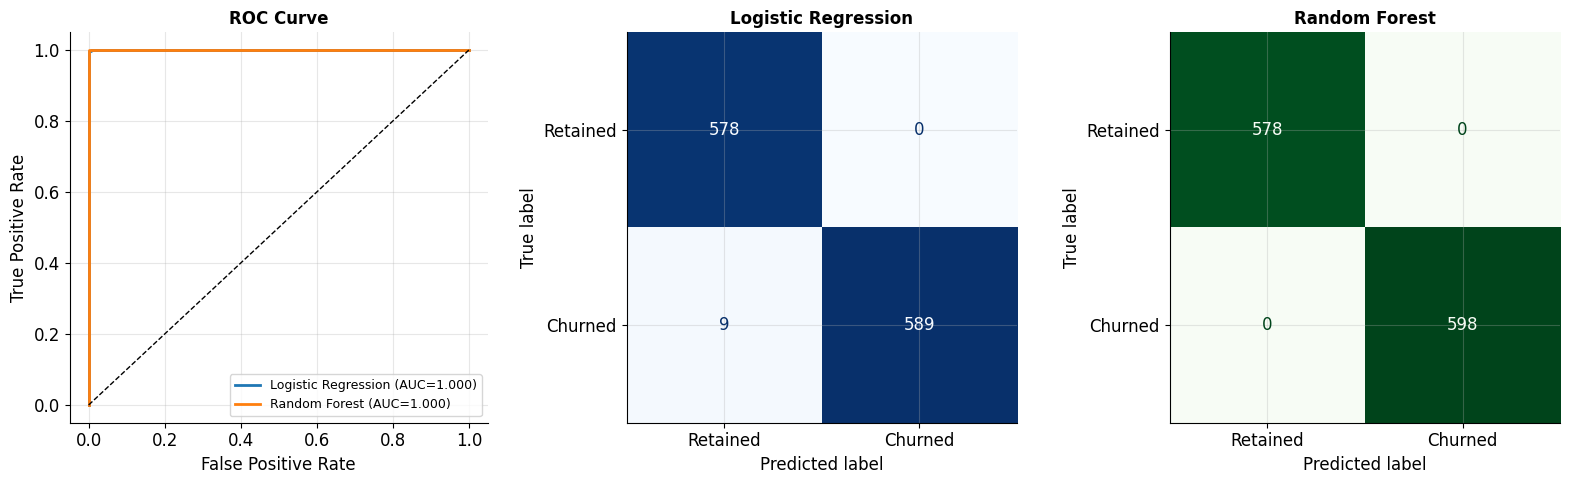

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=2)
ax.plot([0,1], [0,1], "k--", linewidth=1)
ax.set_title("ROC Curve", fontsize=12, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)

# Confusion Matrix — Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, results["Logistic Regression"]["y_pred"],
    display_labels=["Retained", "Churned"],
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Logistic Regression", fontsize=12, fontweight="bold")

# Confusion Matrix — Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, results["Random Forest"]["y_pred"],
    display_labels=["Retained", "Churned"],
    ax=axes[2], colorbar=False, cmap="Greens"
)
axes[2].set_title("Random Forest", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/roc_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. 피처 중요도 (Random Forest)

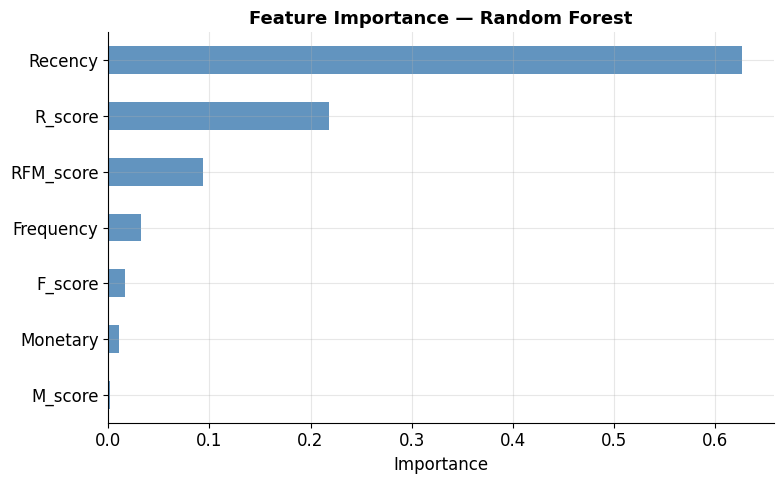


피처 중요도:
Recency      0.6272
R_score      0.2178
RFM_score    0.0935
Frequency    0.0326
F_score      0.0162
Monetary     0.0110
M_score      0.0017
dtype: float64


In [11]:
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="steelblue", alpha=0.85)
ax.set_title("Feature Importance — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n피처 중요도:")
print(importances.sort_values(ascending=False).round(4))

## 10. 결과 저장

In [12]:
import pyarrow as pa
try:
    pa.unregister_extension_type("pandas.period")
except Exception:
    pass

rfm.to_parquet(MODEL_OUTPUT, index=False)
print(f"Saved → {MODEL_OUTPUT}")
print(f"Columns: {rfm.columns.tolist()}")

Saved → ../data/processed/rfm_clustered.parquet
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'Segment', 'Churned', 'Cluster']
